## Odds ratio analysis of gene loss and gain

Testing whether the odds that genes in an orthogroup are missing, in single copy, or in multiple copies differs significantly between orb-weavers and non-orb-weavers

#### import modules

In [1]:
import os
import sys
import pandas as pd
from importlib import reload


# Set the working directory to the scripts directory
# This is necessary to ensure that the script can find the src directory
# and any other relative paths correctly.
scripts = os.path.abspath('')

# Ensure the src directory is in the Python path
src_path = os.path.abspath(os.path.join(scripts, '..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

# Define path data directorie
data = os.path.join(scripts, "..", "data")

# Import the odds_ratio_test function from the src module
import src.odds_ratio_test as ort
reload(ort)

/Users/calvin/anaconda3/envs/orb-selection/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'src.odds_ratio_test' from '/Users/calvin/orb-selection/src/odds_ratio_test.py'>

In [2]:
%load_ext autoreload
%autoreload 2

#### specify input files

In [3]:
genecount_csv = f"{data}/N5.GeneCount.csv"
orb_list_filename = f"{data}/orbweavers-list.txt"
hog_node_genes_tsv = f"{data}/N5.tsv"


Testing for loss of genes first, using occupancy threshold of 75 (same as HyPhy analysis) 

In [28]:
from importlib import reload
reload(ort)

results_dir = f"{data}/loss-test"

bootstrap_nomax = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    results_dir,
    "loss",
    occupancy_threshold=75,
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers
Launching bootstrapping test

** Minimum occupancy set to 75 **

Skew of LOR distribution: -0.2956901521341287
Standard deviation of LOR distribution: 1.2618789667271317
Mean of LOR distribution: -0.3058312386551137



100%|██████████| 10000/10000 [01:15<00:00, 132.76it/s]

Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.07030122101776662
Average bootstrapping stddev: 0.7613340626679499
Average bootstrapping alpha=0.05: -1.1819818732833107

Filtering for occupancy >= 75, <= 98, and log odds ratio threshold 1.1819818732833107
No annotations saved, just returning filtered DataFrame and counts of hits.


Total significant hits: 1713, including U. diversus: 1445

Bootstrapping test with 10000 repetitions for loss (left-tailed)
 with 75 minimum occupancy and no maximum occupancy 


Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt

Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv

Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv


Total number of HOGs in node: 107986
Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True skew: -0.2956901521341287
True mean: -0.3058312386551137
True standard deviation: 1.2618789667271317




In [8]:
bootstrap_95 = ort.odds_ratio_test(
    genecount_csv,
    orb_list_filename,
    hog_node_genes_tsv,
    results_dir,
    "loss",
    occupancy_threshold=75,
    max_occ=95
)

Number of columns before dropping empty columns: 103
98 spiders total, 44 orb-weavers, 54 non-orb-weavers
Launching bootstrapping test

** Maximum occupancy set to 95 **

** Minimum occupancy set to 75 **

Skew of LOR distribution: 0.14789325395694103
Standard deviation of LOR distribution: 1.5374700980875577
Mean of LOR distribution: -0.6300388762633876



100%|██████████| 10000/10000 [01:04<00:00, 155.74it/s]

Bootstrapping counter: 0
Probability that null is true: 0.00

Average bootstrapping mean: 0.0009885735342439032
Average bootstrapping stddev: 0.7385762959381243
Average bootstrapping alpha=0.05: -1.2138613256199644

Filtering for occupancy >= 75, <= 95, and log odds ratio threshold 1.2138613256199644
No annotations saved, just returning filtered DataFrame and counts of hits.


Total significant hits: 1188, including U. diversus: 949

Bootstrapping test with 10000 repetitions for loss (left-tailed)
 with 75 minimum occupancy and 95 maximum occupancy 


Orb-weaver list: /Users/calvin/orb-selection/scripts/../data/orbweavers-list.txt

Gene count file: /Users/calvin/orb-selection/scripts/../data/N5.GeneCount.csv

Hierarchical orthogroup file: /Users/calvin/orb-selection/scripts/../data/N5.tsv


Total spiders: 98
Orb-weavers: 44
Non-orb-weavers: 54
True skew: 0.14789325395694103
True mean: -0.6300388762633876
True standard deviation: 1.5374700980875577


Bootstrapped average skew: -0.057777

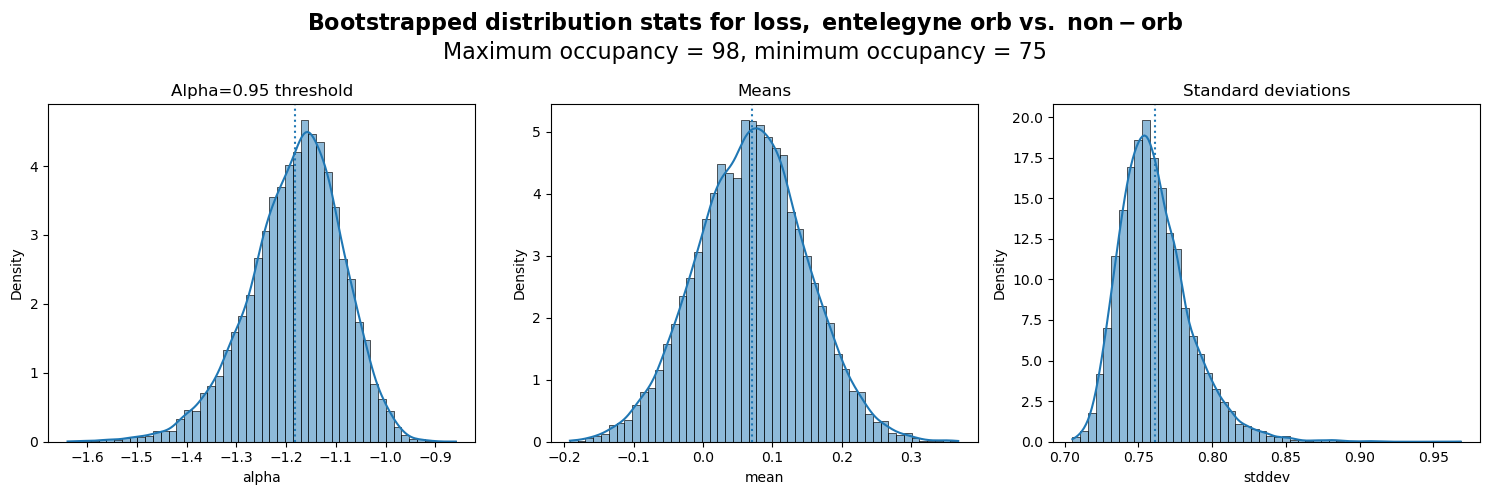

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Alpha=0.95 threshold'}, xlabel='alpha', ylabel='Density'>,
        <Axes: title={'center': 'Means'}, xlabel='mean', ylabel='Density'>,
        <Axes: title={'center': 'Standard deviations'}, xlabel='stddev', ylabel='Density'>],
       dtype=object))

In [29]:
text = "loss, entelegyne orb vs. non-orb".replace(" ", "\ ")
bootstrap_nomax.plot_bootstrap_stats(hist_txt=text)

updated!


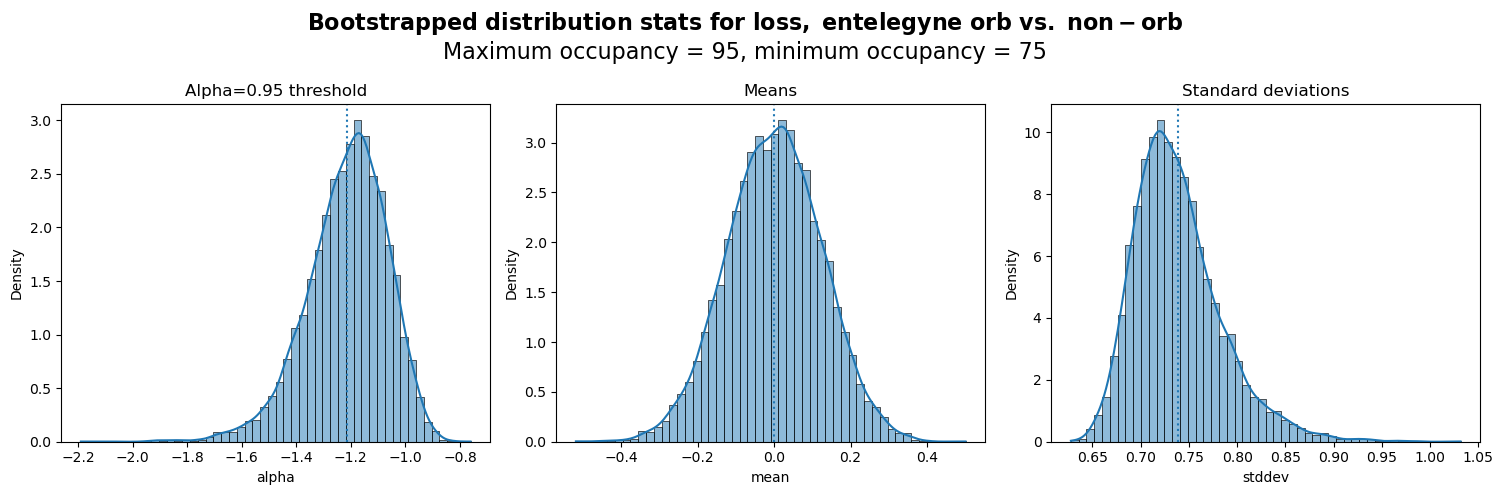

(<Figure size 1500x500 with 3 Axes>,
 array([<Axes: title={'center': 'Alpha=0.95 threshold'}, xlabel='alpha', ylabel='Density'>,
        <Axes: title={'center': 'Means'}, xlabel='mean', ylabel='Density'>,
        <Axes: title={'center': 'Standard deviations'}, xlabel='stddev', ylabel='Density'>],
       dtype=object))

In [19]:
bootstrap_95.plot_bootstrap_stats(hist_txt=text)

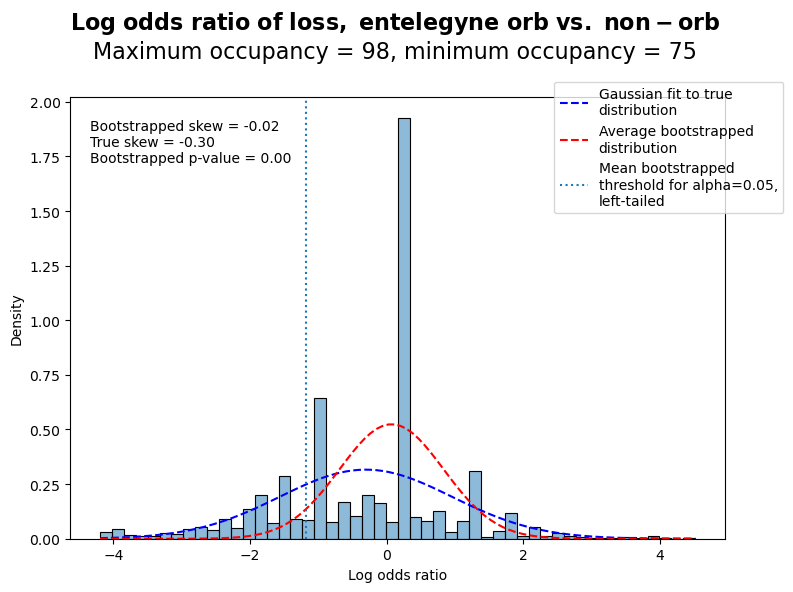

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

In [30]:
bootstrap_nomax.plot_bootstrap_results(
    plot_name=text)

updated!


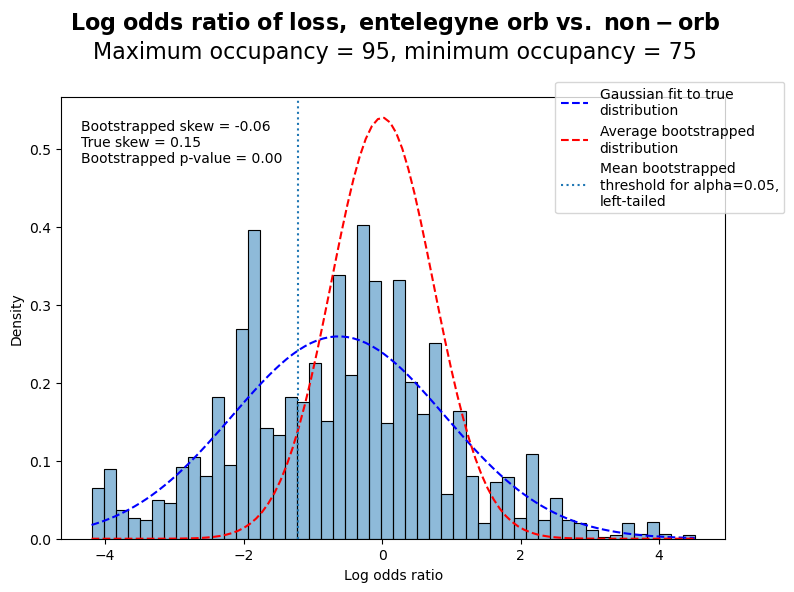

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

In [27]:
bootstrap_95.plot_bootstrap_results(
    plot_name=text)